# Prueba de Progreso 1: Predicción de la Calidad del Vino

## Clasificación vs Regresión

**Autor:** Daniel Tomas Gallego  
**Asignatura:** Técnicas de Aprendizaje Automático  
**Curso:** 2026  
**Universidad:** UCLM (Universidad de Castilla-La Mancha)

---

### Descripción del problema

El objetivo de esta práctica es predecir la **calidad del vino** a partir de sus propiedades químicas, utilizando dos enfoques diferentes del aprendizaje automático:

1. **Regresión:** Tratando la calidad como una variable continua.
2. **Clasificación:** Tratando la calidad como una variable categórica.

Para cada enfoque se probarán **tres algoritmos distintos**, se evaluará su desempeño con métricas adecuadas y se seleccionará el mejor. Finalmente, se compararán ambos enfoques para determinar cuál es más adecuado para este problema.

**Algoritmos a probar:**
- **Random Forest** (Regresión y Clasificación)
- **Decision Tree** (Regresión y Clasificación)
- **Naive Bayes / Bayesian Ridge** (GaussianNB para clasificación, BayesianRidge para regresión)

## 1. Instalación e Importación de Librerías

Instalamos las dependencias necesarias e importamos todas las librerías que utilizaremos a lo largo del cuaderno.

In [13]:
# Instalación del paquete para descargar datasets de UCI
%pip install ucimlrepo --quiet

Note: you may need to restart the kernel to use updated packages.


In [14]:
# Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
warnings.filterwarnings('ignore')

# Carga del dataset
from ucimlrepo import fetch_ucirepo

# Modelos de regresión
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import BayesianRidge

# Modelos de clasificación
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Preprocesamiento y validación
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize

# Métricas de regresión
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Métricas de clasificación
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score,
    accuracy_score, roc_curve, auc, precision_score, recall_score
)

print("Todas las librerías importadas correctamente.")

Todas las librerías importadas correctamente.


## 2. Carga y Exploración del Dataset

Descargamos el dataset de calidad del vino desde el repositorio UCI Machine Learning. Este dataset contiene propiedades fisicoquímicas de vinos tintos y blancos junto con una puntuación de calidad asignada por catadores.

In [15]:
# Descarga del dataset de calidad del vino
wine_quality = fetch_ucirepo(id=186)

# Datos brutos en formato DataFrame de pandas
X = wine_quality.data.features
y = wine_quality.data.targets

# Mostrar metadatos del dataset
print("=" * 60)
print("METADATOS DEL DATASET")
print("=" * 60)
print(f"Nombre: {wine_quality.metadata['name']}")
print(f"Número de instancias: {wine_quality.metadata['num_instances']}")
print(f"Número de características: {wine_quality.metadata['num_features']}")
print(f"Área: {wine_quality.metadata['area']}")

METADATOS DEL DATASET
Nombre: Wine Quality
Número de instancias: 4898
Número de características: 11
Área: Business


In [16]:
# Información de las variables
print("INFORMACIÓN DE LAS VARIABLES")
print("=" * 60)
print(wine_quality.variables[['name', 'role', 'type', 'missing_values']])

INFORMACIÓN DE LAS VARIABLES
                    name     role         type missing_values
0          fixed_acidity  Feature   Continuous             no
1       volatile_acidity  Feature   Continuous             no
2            citric_acid  Feature   Continuous             no
3         residual_sugar  Feature   Continuous             no
4              chlorides  Feature   Continuous             no
5    free_sulfur_dioxide  Feature   Continuous             no
6   total_sulfur_dioxide  Feature   Continuous             no
7                density  Feature   Continuous             no
8                     pH  Feature   Continuous             no
9              sulphates  Feature   Continuous             no
10               alcohol  Feature   Continuous             no
11               quality   Target      Integer             no
12                 color    Other  Categorical             no


In [17]:
# Combinar características y objetivo en un solo DataFrame para exploración
df = pd.concat([X, y], axis=1)

print(f"\nForma del dataset: {df.shape}")
print(f"Número de muestras: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")
print("\nPrimeras 5 filas del dataset:")
df.head()


Forma del dataset: (6497, 12)
Número de muestras: 6497
Número de columnas: 12

Primeras 5 filas del dataset:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [18]:
# Información general del dataset
print("INFORMACIÓN DEL DATASET")
print("=" * 60)
df.info()

INFORMACIÓN DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


In [19]:
# Estadísticas descriptivas
print("\nESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
df.describe().round(3)


ESTADÍSTICAS DESCRIPTIVAS


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000
mean,7.215,0.340,0.319,5.443,0.056,30.525,115.745,0.995,3.219,0.531,10.492,5.818
std,1.296,0.165,0.145,4.758,0.035,17.749,56.522,0.003,0.161,0.149,1.193,0.873
min,3.800,0.080,0.000,0.600,0.009,1.000,6.000,0.987,2.720,0.220,8.000,3.000
25%,6.400,0.230,0.250,1.800,0.038,17.000,77.000,0.992,3.110,0.430,9.500,5.000
50%,7.000,0.290,0.310,3.000,0.047,29.000,118.000,0.995,3.210,0.510,10.300,6.000
75%,7.700,0.400,0.390,8.100,0.065,41.000,156.000,0.997,3.320,0.600,11.300,6.000
max,15.900,1.580,1.660,65.800,0.611,289.000,440.000,1.039,4.010,2.000,14.900,9.000


In [20]:
# Distribución de la variable objetivo 'quality'
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO 'quality'")
print("=" * 60)
print(y['quality'].value_counts().sort_index())
print(f"\nValores únicos de calidad: {sorted(y['quality'].unique())}")
print(f"Calidad mínima: {y['quality'].min()}")
print(f"Calidad máxima: {y['quality'].max()}")
print(f"Calidad media: {y['quality'].mean():.2f}")
print(f"Calidad mediana: {y['quality'].median()}")

DISTRIBUCIÓN DE LA VARIABLE OBJETIVO 'quality'
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

Valores únicos de calidad: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Calidad mínima: 3
Calidad máxima: 9
Calidad media: 5.82
Calidad mediana: 6.0


## 3. Análisis Exploratorio de Datos (EDA)

En esta sección visualizamos las distribuciones de las variables, las correlaciones entre ellas y realizamos un análisis para comprender mejor la estructura de los datos antes de construir los modelos.

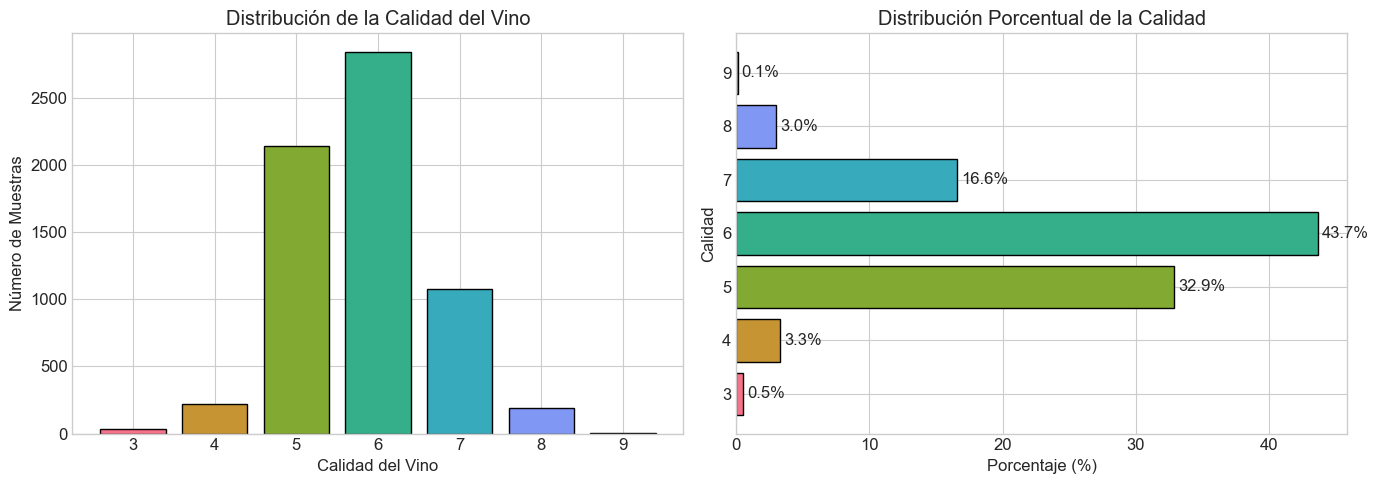


Observación: La distribución de la calidad está desbalanceada,
con la mayoría de los vinos concentrados en las calidades 5, 6 y 7.


In [21]:
# Distribución de la variable objetivo 'quality'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras (countplot)
quality_counts = y['quality'].value_counts().sort_index()
axes[0].bar(quality_counts.index, quality_counts.values,
            color=sns.color_palette("husl", len(quality_counts)), edgecolor='black')
axes[0].set_xlabel('Calidad del Vino')
axes[0].set_ylabel('Número de Muestras')
axes[0].set_title('Distribución de la Calidad del Vino')
axes[0].set_xticks(quality_counts.index)

# Porcentajes
porcentajes = (quality_counts / quality_counts.sum() * 100).round(1)
axes[1].barh(porcentajes.index.astype(str), porcentajes.values,
             color=sns.color_palette("husl", len(porcentajes)), edgecolor='black')
axes[1].set_xlabel('Porcentaje (%)')
axes[1].set_ylabel('Calidad')
axes[1].set_title('Distribución Porcentual de la Calidad')
for i, v in enumerate(porcentajes.values):
    axes[1].text(v + 0.3, i, f'{v}%', va='center')

plt.tight_layout()
plt.show()

print("\nObservación: La distribución de la calidad está desbalanceada,")
print("con la mayoría de los vinos concentrados en las calidades 5, 6 y 7.")

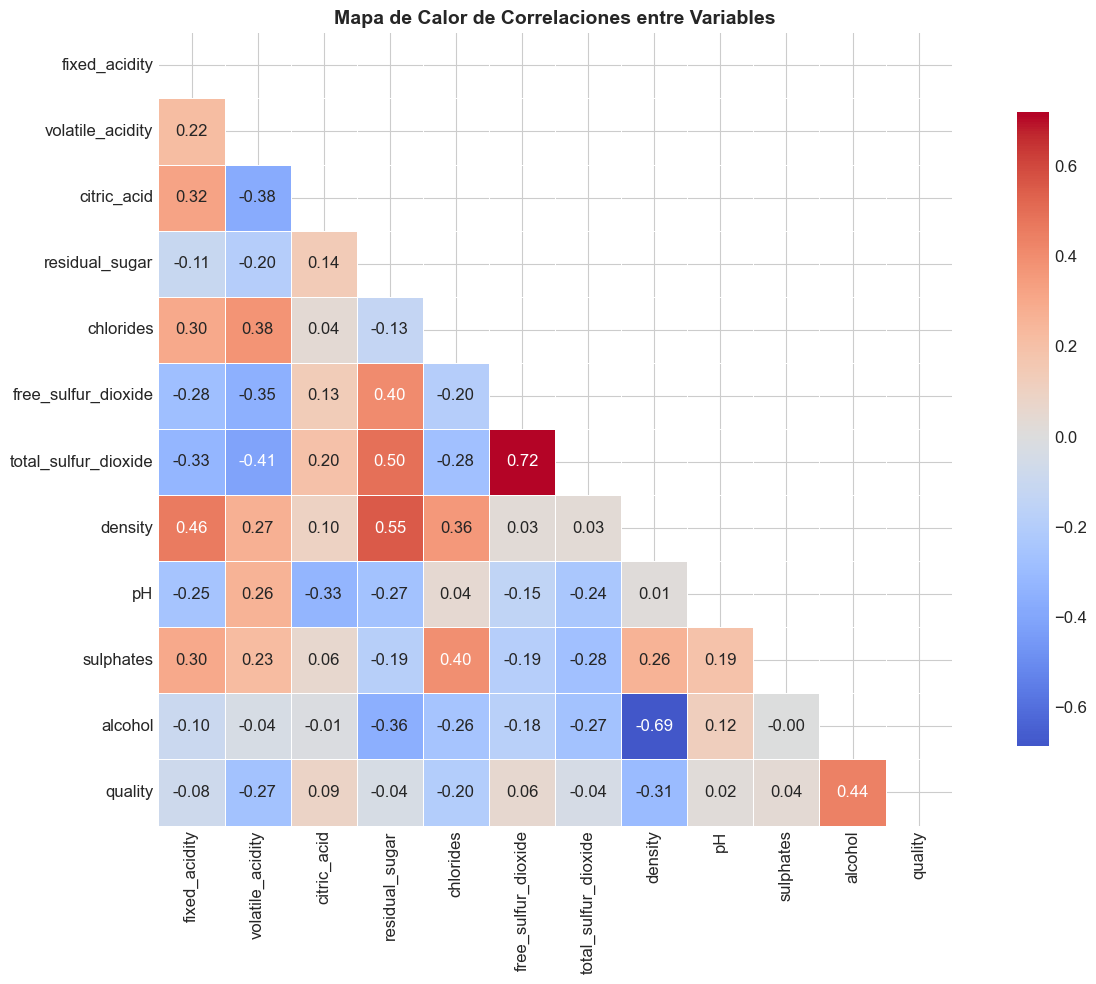


Correlaciones con la variable 'quality' (ordenadas por valor absoluto):
alcohol                 0.444
density                 0.306
volatile_acidity        0.266
chlorides               0.201
citric_acid             0.086
fixed_acidity           0.077
free_sulfur_dioxide     0.055
total_sulfur_dioxide    0.041
sulphates               0.038
residual_sugar          0.037
pH                      0.020
Name: quality, dtype: float64


In [22]:
# Mapa de calor de correlaciones
fig, ax = plt.subplots(figsize=(14, 10))
correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title('Mapa de Calor de Correlaciones entre Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Mostrar las correlaciones con la variable objetivo
print("\nCorrelaciones con la variable 'quality' (ordenadas por valor absoluto):")
corr_with_quality = correlation_matrix['quality'].drop('quality').abs().sort_values(ascending=False)
print(corr_with_quality.round(3))

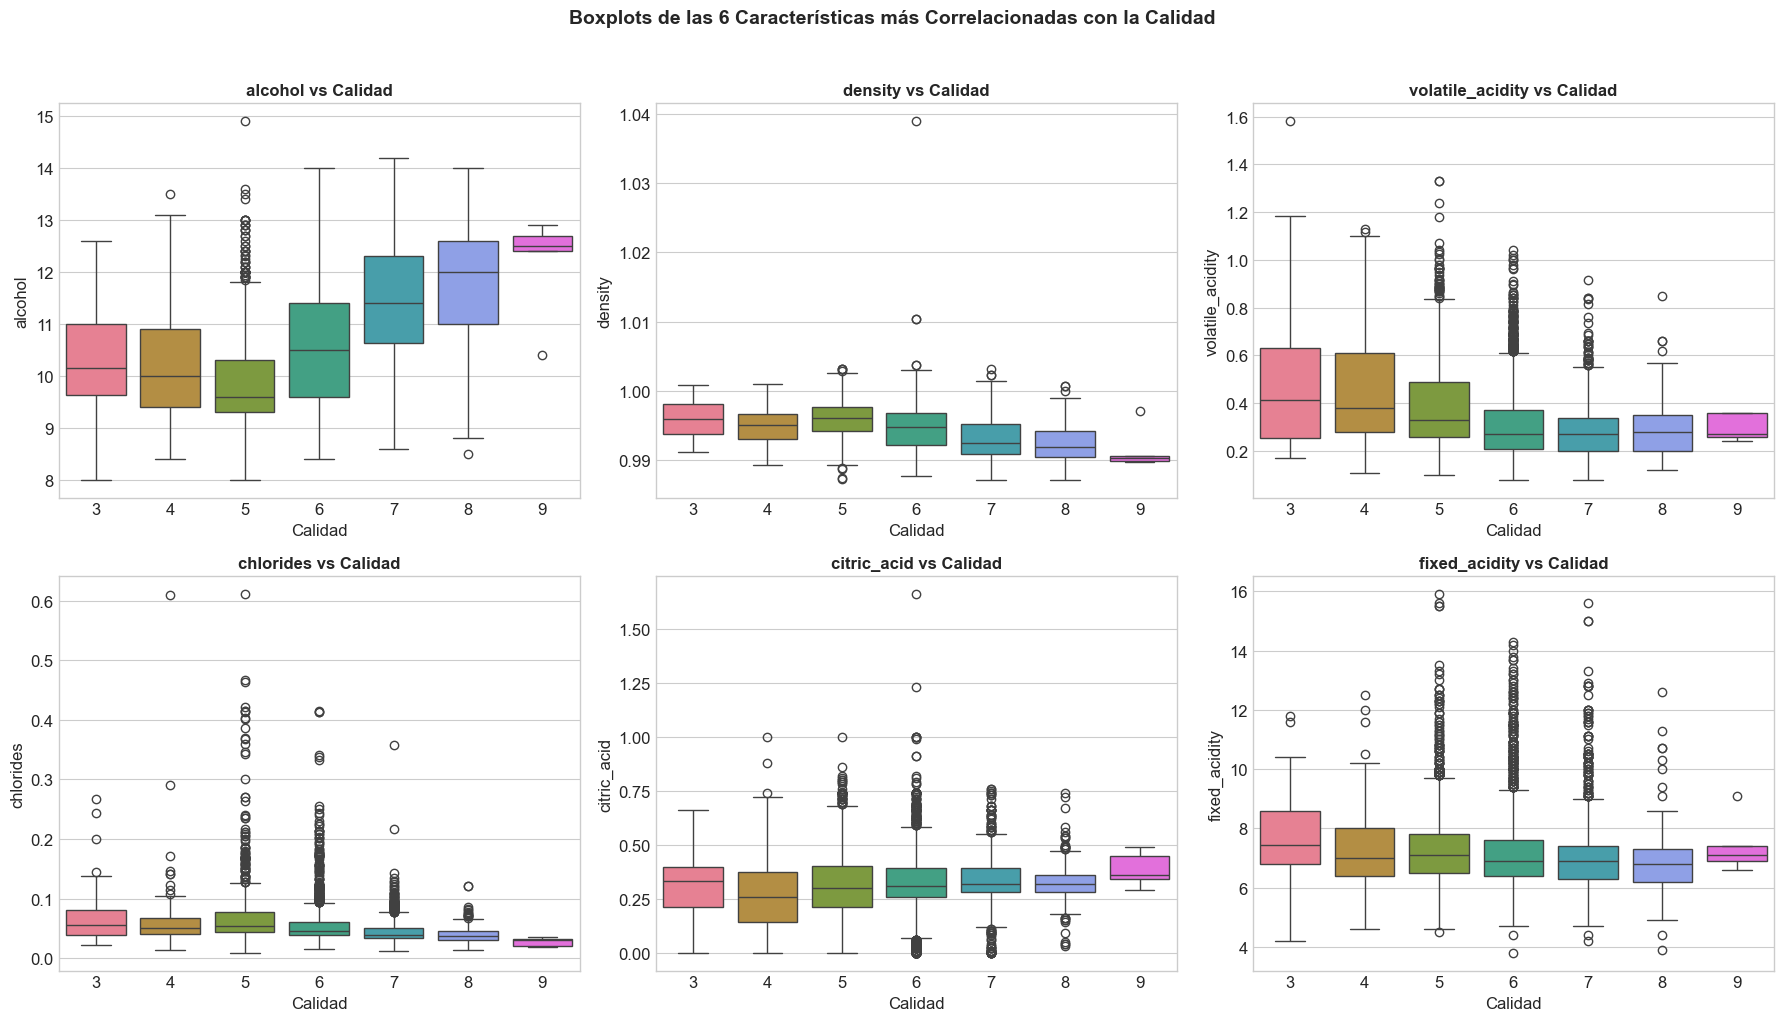

In [23]:
# Boxplots de las características más correlacionadas con la calidad
top_features = corr_with_quality.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.boxplot(x='quality', y=feature, data=df, ax=axes[i], palette='husl')
    axes[i].set_title(f'{feature} vs Calidad', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Calidad')
    axes[i].set_ylabel(feature)

plt.suptitle('Boxplots de las 6 Características más Correlacionadas con la Calidad',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

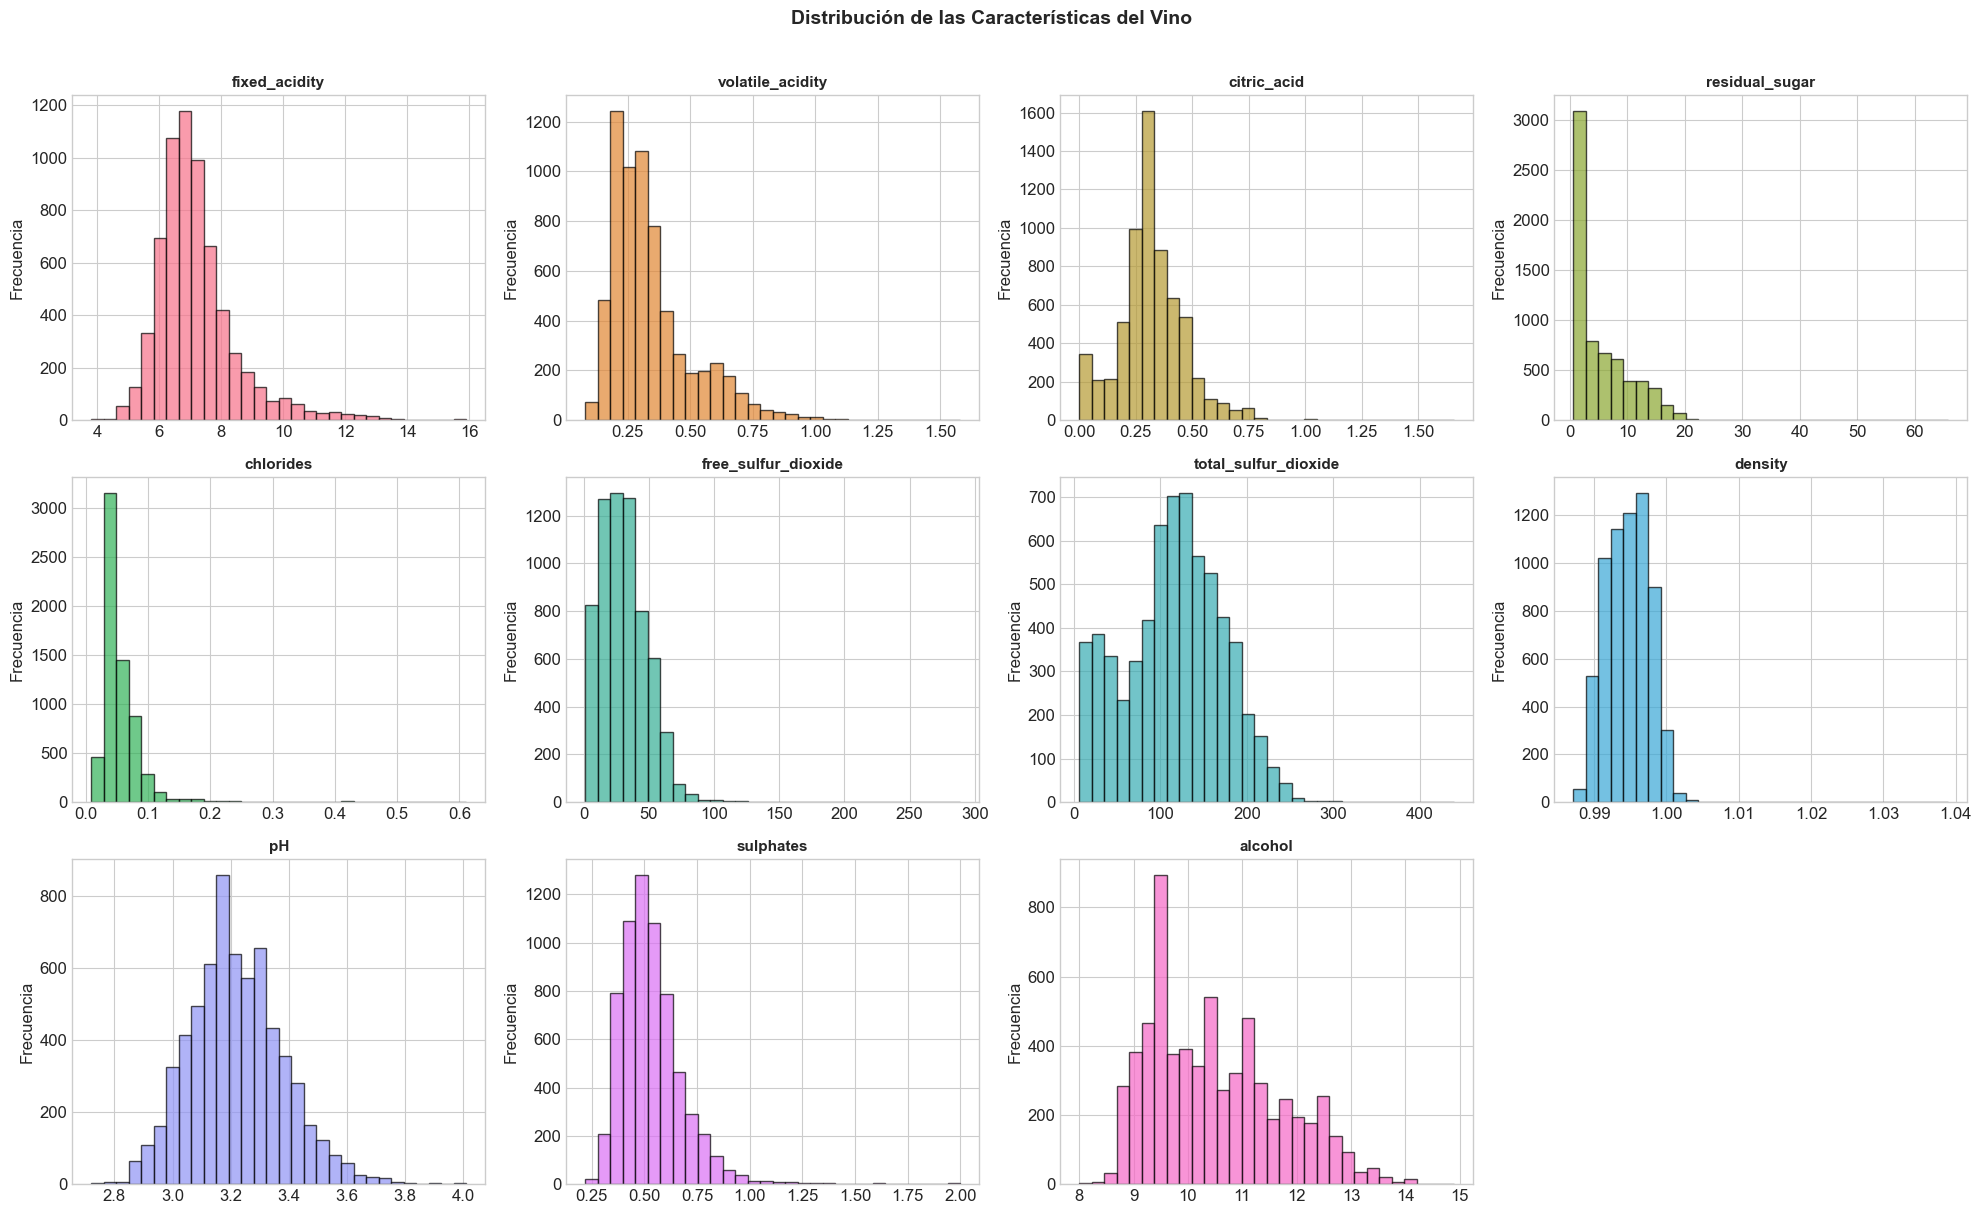

In [24]:
# Distribución de todas las características
n_features = len(X.columns)
palette = sns.color_palette("husl", n_features)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    axes[i].hist(X[col], bins=30, edgecolor='black', alpha=0.7, color=palette[i])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

# Ocultar subplots vacíos
for j in range(len(X.columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de las Características del Vino', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Hallazgos del EDA

1. **Desbalance de clases:** La variable `quality` está muy concentrada en los valores 5, 6 y 7. Los extremos (3, 4, 8, 9) tienen muy pocas muestras, lo que puede dificultar la clasificación.
2. **Correlaciones:** Las características con mayor correlación con la calidad son el alcohol (positiva), la densidad y la acidez volátil (negativas).
3. **Distribuciones:** Varias características presentan distribuciones sesgadas (residual_sugar, chlorides, free/total_sulfur_dioxide), lo que justifica la estandarización.
4. **No hay valores faltantes:** El dataset está completo, lo que simplifica el preprocesamiento.

## 4. Preprocesamiento de Datos

Preparamos los datos para el modelado: verificamos valores faltantes, estandarizamos las características y preparamos la variable objetivo para ambos enfoques.

In [25]:
# Verificar valores faltantes
print("VALORES FALTANTES POR COLUMNA")
print("=" * 40)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal de valores faltantes: {missing.sum()}")
print("\n✓ No hay valores faltantes en el dataset.")

VALORES FALTANTES POR COLUMNA
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total de valores faltantes: 0

✓ No hay valores faltantes en el dataset.


In [26]:
# Preparar la variable objetivo para ambos enfoques

# Para REGRESIÓN: quality como variable continua (numérica)
y_reg = y['quality'].values.astype(float)

# Para CLASIFICACIÓN: quality como variable categórica (entera)
y_clf = y['quality'].values.astype(int)

print("Variable objetivo para regresión (continua):")
print(f"  Tipo: {y_reg.dtype}, Rango: [{y_reg.min()}, {y_reg.max()}]")
print(f"\nVariable objetivo para clasificación (categórica):")
print(f"  Tipo: {y_clf.dtype}, Clases: {sorted(np.unique(y_clf))}")

print("\n" + "=" * 60)
print("JUSTIFICACIÓN DEL PREPROCESAMIENTO")
print("=" * 60)
print("""
- Estandarización (StandardScaler): Se aplica a las características para que todas
  tengan media 0 y desviación estándar 1. Esto es importante porque las variables
  tienen escalas muy diferentes (ej: total_sulfur_dioxide vs pH).
- No se eliminan valores atípicos para mantener la integridad de los datos.
- No se aplica balanceo de clases para mantener la distribución original.
""")

Variable objetivo para regresión (continua):
  Tipo: float64, Rango: [3.0, 9.0]

Variable objetivo para clasificación (categórica):
  Tipo: int64, Clases: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

JUSTIFICACIÓN DEL PREPROCESAMIENTO

- Estandarización (StandardScaler): Se aplica a las características para que todas
  tengan media 0 y desviación estándar 1. Esto es importante porque las variables
  tienen escalas muy diferentes (ej: total_sulfur_dioxide vs pH).
- No se eliminan valores atípicos para mantener la integridad de los datos.
- No se aplica balanceo de clases para mantener la distribución original.



## 5. División del Dataset (Train/Test Split)

Dividimos el dataset en conjuntos de entrenamiento (80%) y prueba (20%), utilizando la **misma partición** para ambos enfoques (regresión y clasificación) para que la comparación sea justa.

In [27]:
# División del dataset: 80% entrenamiento, 20% prueba
# Usamos random_state=42 para reproducibilidad
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Misma partición para clasificación
_, _, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

# Estandarización de las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("DIVISIÓN DEL DATASET")
print("=" * 40)
print(f"Conjunto de entrenamiento: {X_train_scaled.shape[0]} muestras ({X_train_scaled.shape[0]/len(X)*100:.1f}%)")
print(f"Conjunto de prueba:        {X_test_scaled.shape[0]} muestras ({X_test_scaled.shape[0]/len(X)*100:.1f}%)")
print(f"Número de características: {X_train_scaled.shape[1]}")
print(f"\nDistribución de calidad en entrenamiento:")
unique, counts = np.unique(y_train_clf, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Calidad {u}: {c} muestras ({c/len(y_train_clf)*100:.1f}%)")

DIVISIÓN DEL DATASET
Conjunto de entrenamiento: 5197 muestras (80.0%)
Conjunto de prueba:        1300 muestras (20.0%)
Número de características: 11

Distribución de calidad en entrenamiento:
  Calidad 3: 24 muestras (0.5%)
  Calidad 4: 173 muestras (3.3%)
  Calidad 5: 1736 muestras (33.4%)
  Calidad 6: 2239 muestras (43.1%)
  Calidad 7: 864 muestras (16.6%)
  Calidad 8: 157 muestras (3.0%)
  Calidad 9: 4 muestras (0.1%)


---

## 6. REGRESIÓN: Predicción de la Calidad como Variable Continua

En esta sección tratamos la calidad del vino como una **variable continua** y entrenamos tres modelos de regresión:

1. **Random Forest Regressor:** Conjunto de árboles de decisión que promedian sus predicciones. Es robusto ante el overfitting y maneja bien relaciones no lineales.
2. **Decision Tree Regressor:** Un único árbol de decisión. Es interpretable pero propenso al sobreajuste.
3. **Bayesian Ridge:** Regresión bayesiana que estima distribuciones de probabilidad sobre los pesos. Se usa como alternativa a Naive Bayes, ya que GaussianNB no soporta regresión directamente.

> **Nota:** Se utiliza BayesianRidge en lugar de GaussianNB para regresión porque Naive Bayes es un algoritmo exclusivo de clasificación. BayesianRidge es un método bayesiano equivalente para tareas de regresión.

In [28]:
# ============================================================
# MODELO 1: Random Forest Regressor
# ============================================================
print("MODELO 1: RANDOM FOREST REGRESSOR")
print("=" * 60)

# Definir los hiperparámetros a probar
param_grid_rf_reg = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV con validación cruzada (5-fold)
rf_reg = RandomForestRegressor(random_state=42)
grid_rf_reg = GridSearchCV(
    rf_reg, param_grid_rf_reg,
    cv=5, scoring='r2', n_jobs=-1, verbose=0
)
grid_rf_reg.fit(X_train_scaled, y_train_reg)

# Mejores hiperparámetros
print(f"Mejores hiperparámetros: {grid_rf_reg.best_params_}")
print(f"Mejor R² en validación cruzada: {grid_rf_reg.best_score_:.4f}")

# Predicciones
y_pred_rf_reg = grid_rf_reg.predict(X_test_scaled)

MODELO 1: RANDOM FOREST REGRESSOR
Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Mejor R² en validación cruzada: 0.5067


In [29]:
# ============================================================
# MODELO 2: Decision Tree Regressor
# ============================================================
print("MODELO 2: DECISION TREE REGRESSOR")
print("=" * 60)

param_grid_dt_reg = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['squared_error', 'friedman_mse']
}

dt_reg = DecisionTreeRegressor(random_state=42)
grid_dt_reg = GridSearchCV(
    dt_reg, param_grid_dt_reg,
    cv=5, scoring='r2', n_jobs=-1, verbose=0
)
grid_dt_reg.fit(X_train_scaled, y_train_reg)

print(f"Mejores hiperparámetros: {grid_dt_reg.best_params_}")
print(f"Mejor R² en validación cruzada: {grid_dt_reg.best_score_:.4f}")

y_pred_dt_reg = grid_dt_reg.predict(X_test_scaled)

MODELO 2: DECISION TREE REGRESSOR
Mejores hiperparámetros: {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 2}
Mejor R² en validación cruzada: 0.2997


In [30]:
# ============================================================
# MODELO 3: Bayesian Ridge Regressor
# ============================================================
print("MODELO 3: BAYESIAN RIDGE REGRESSOR")
print("=" * 60)
print("Nota: Se usa BayesianRidge como alternativa bayesiana a Naive Bayes,")
print("ya que GaussianNB es un algoritmo exclusivo de clasificación.\n")

param_grid_br = {
    'alpha_1': [1e-6, 1e-5, 1e-4],
    'alpha_2': [1e-6, 1e-5, 1e-4],
    'lambda_1': [1e-6, 1e-5, 1e-4],
    'lambda_2': [1e-6, 1e-5, 1e-4]
}

br_reg = BayesianRidge()
grid_br_reg = GridSearchCV(
    br_reg, param_grid_br,
    cv=5, scoring='r2', n_jobs=-1, verbose=0
)
grid_br_reg.fit(X_train_scaled, y_train_reg)

print(f"Mejores hiperparámetros: {grid_br_reg.best_params_}")
print(f"Mejor R² en validación cruzada: {grid_br_reg.best_score_:.4f}")

y_pred_br_reg = grid_br_reg.predict(X_test_scaled)

MODELO 3: BAYESIAN RIDGE REGRESSOR
Nota: Se usa BayesianRidge como alternativa bayesiana a Naive Bayes,
ya que GaussianNB es un algoritmo exclusivo de clasificación.

Mejores hiperparámetros: {'alpha_1': 1e-06, 'alpha_2': 0.0001, 'lambda_1': 0.0001, 'lambda_2': 1e-06}
Mejor R² en validación cruzada: 0.2953


## 7. Evaluación de los Modelos de Regresión

Evaluamos los tres modelos de regresión con las métricas: **MAE** (Error Absoluto Medio), **MSE** (Error Cuadrático Medio), **RMSE** (Raíz del Error Cuadrático Medio) y **R²** (Coeficiente de Determinación).

In [31]:
# Calcular métricas para los tres modelos de regresión
modelos_reg = {
    'Random Forest': y_pred_rf_reg,
    'Decision Tree': y_pred_dt_reg,
    'Bayesian Ridge': y_pred_br_reg
}

resultados_reg = {}
for nombre, y_pred in modelos_reg.items():
    mae = mean_absolute_error(y_test_reg, y_pred)
    mse = mean_squared_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_reg, y_pred)
    resultados_reg[nombre] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R²': r2}

# Tabla comparativa
df_resultados_reg = pd.DataFrame(resultados_reg).T
df_resultados_reg = df_resultados_reg.round(4)

print("TABLA COMPARATIVA - MODELOS DE REGRESIÓN")
print("=" * 60)
print(df_resultados_reg.to_string())

# Destacar el mejor modelo
mejor_reg = df_resultados_reg['R²'].idxmax()
print(f"\n★ Mejor modelo de regresión: {mejor_reg} (R² = {df_resultados_reg.loc[mejor_reg, 'R²']:.4f})")

TABLA COMPARATIVA - MODELOS DE REGRESIÓN
                   MAE     MSE    RMSE      R²
Random Forest   0.4359  0.3688  0.6073  0.5006
Decision Tree   0.5715  0.5615  0.7493  0.2398
Bayesian Ridge  0.5658  0.5462  0.7391  0.2604

★ Mejor modelo de regresión: Random Forest (R² = 0.5006)


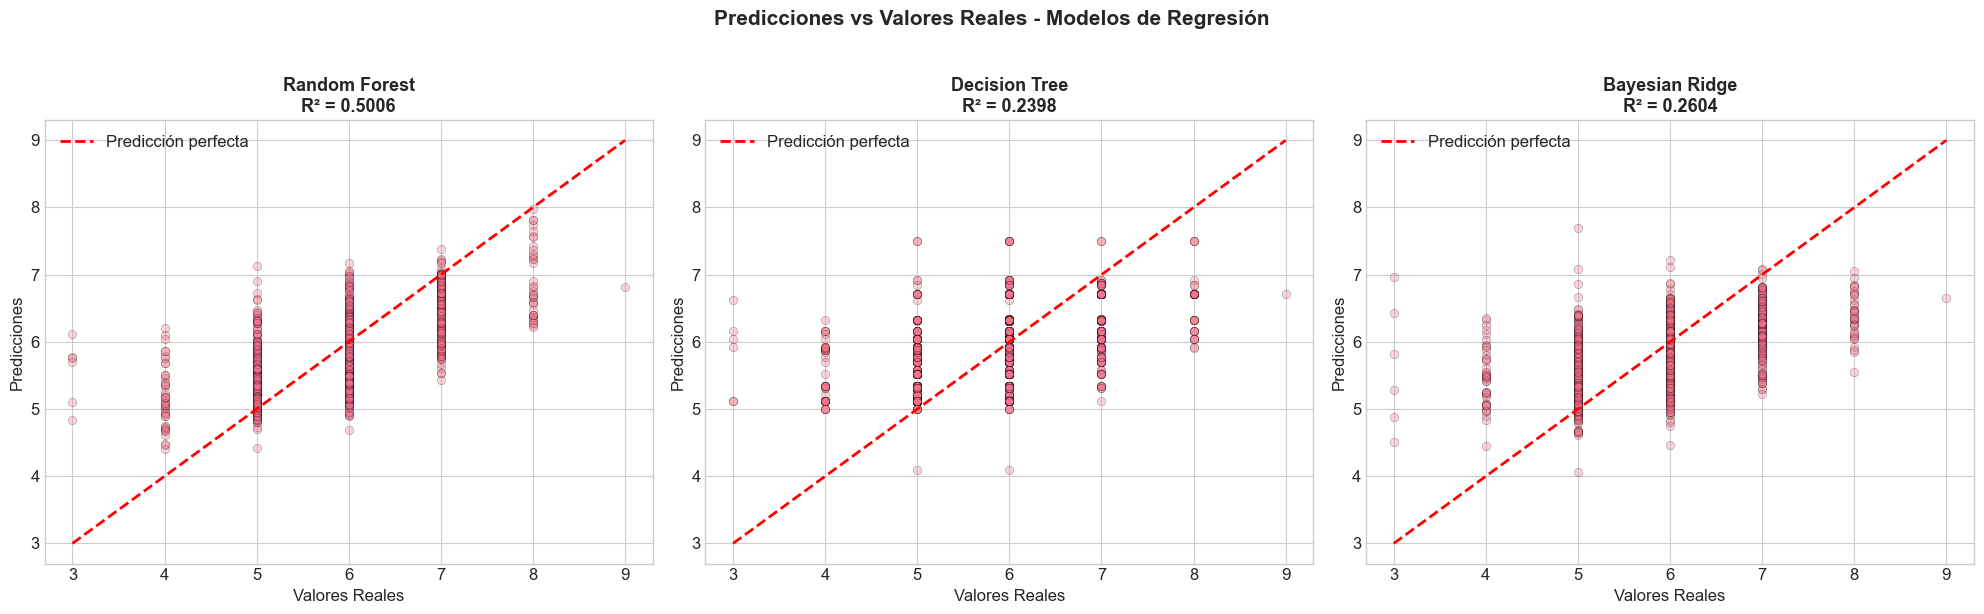

In [32]:
# Visualización: Predicciones vs Valores Reales para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (nombre, y_pred) in enumerate(modelos_reg.items()):
    axes[i].scatter(y_test_reg, y_pred, alpha=0.3, edgecolors='black', linewidth=0.5)
    axes[i].plot([y_test_reg.min(), y_test_reg.max()],
                 [y_test_reg.min(), y_test_reg.max()], 'r--', linewidth=2, label='Predicción perfecta')
    axes[i].set_xlabel('Valores Reales', fontsize=12)
    axes[i].set_ylabel('Predicciones', fontsize=12)
    r2 = resultados_reg[nombre]['R²']
    axes[i].set_title(f'{nombre}\nR² = {r2:.4f}', fontsize=13, fontweight='bold')
    axes[i].legend()

plt.suptitle('Predicciones vs Valores Reales - Modelos de Regresión',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

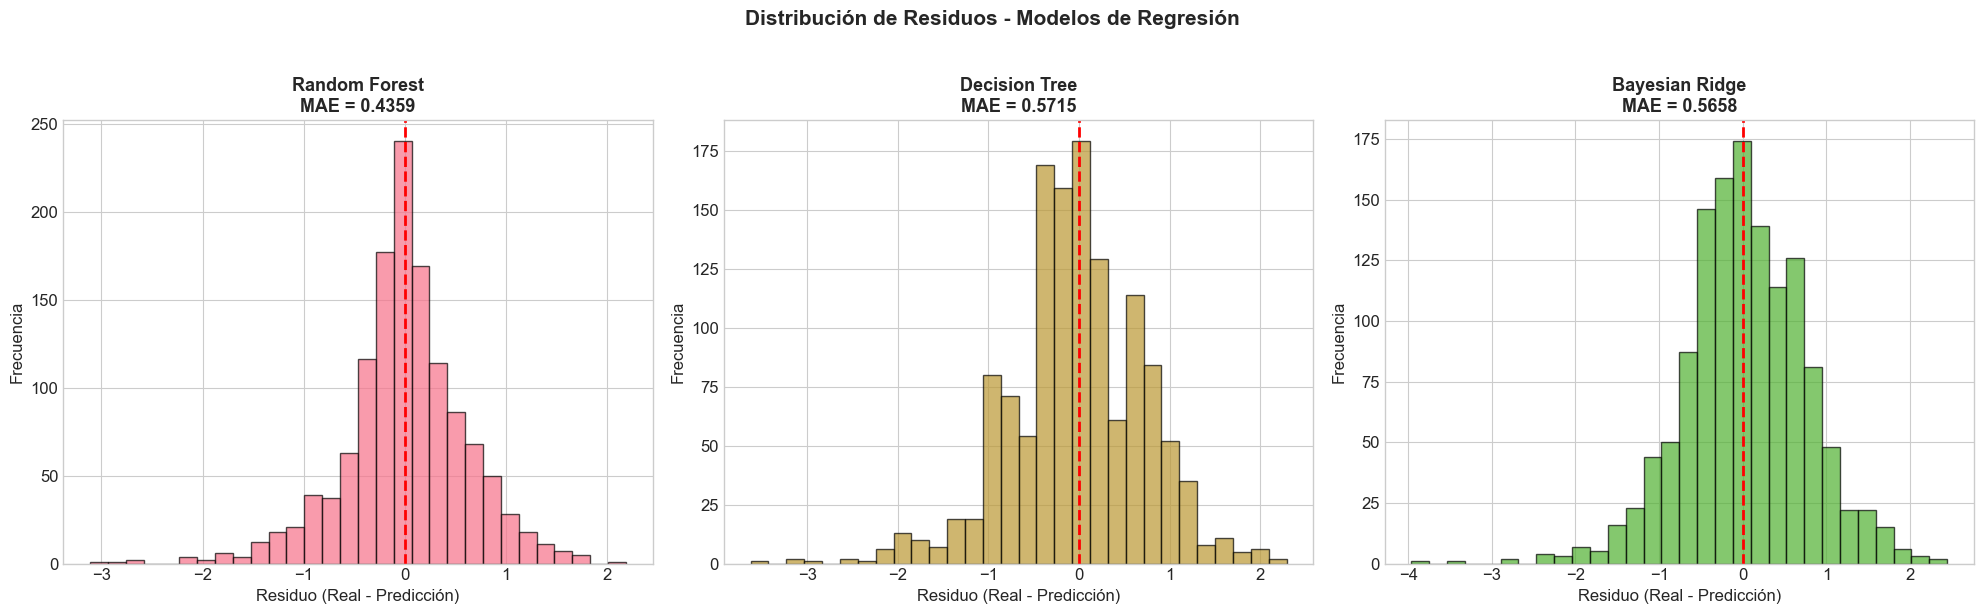

In [33]:
# Distribución de residuos para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (nombre, y_pred) in enumerate(modelos_reg.items()):
    residuos = y_test_reg - y_pred
    axes[i].hist(residuos, bins=30, edgecolor='black', alpha=0.7,
                 color=sns.color_palette("husl")[i])
    axes[i].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[i].set_xlabel('Residuo (Real - Predicción)', fontsize=12)
    axes[i].set_ylabel('Frecuencia', fontsize=12)
    mae = resultados_reg[nombre]['MAE']
    axes[i].set_title(f'{nombre}\nMAE = {mae:.4f}', fontsize=13, fontweight='bold')

plt.suptitle('Distribución de Residuos - Modelos de Regresión',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Selección del Mejor Modelo de Regresión

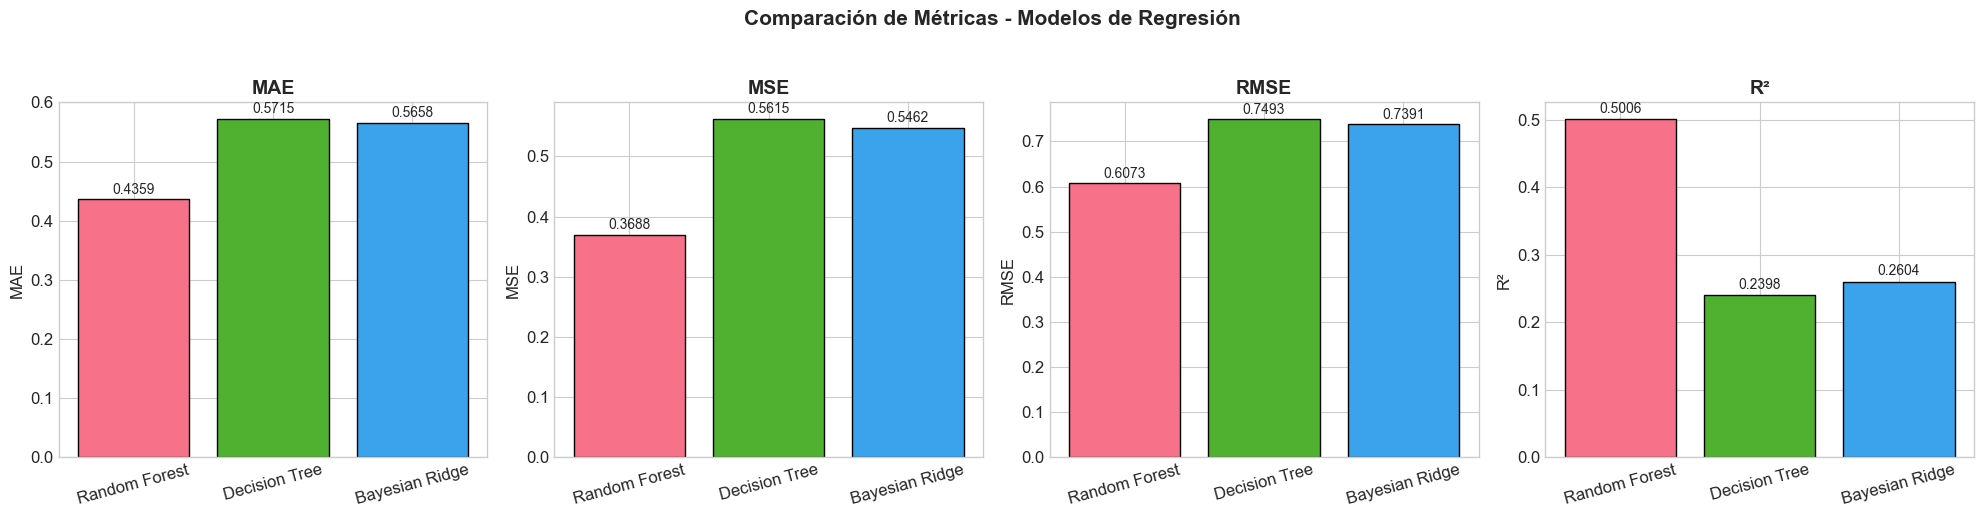


SELECCIÓN: MEJOR MODELO DE REGRESIÓN -> Random Forest


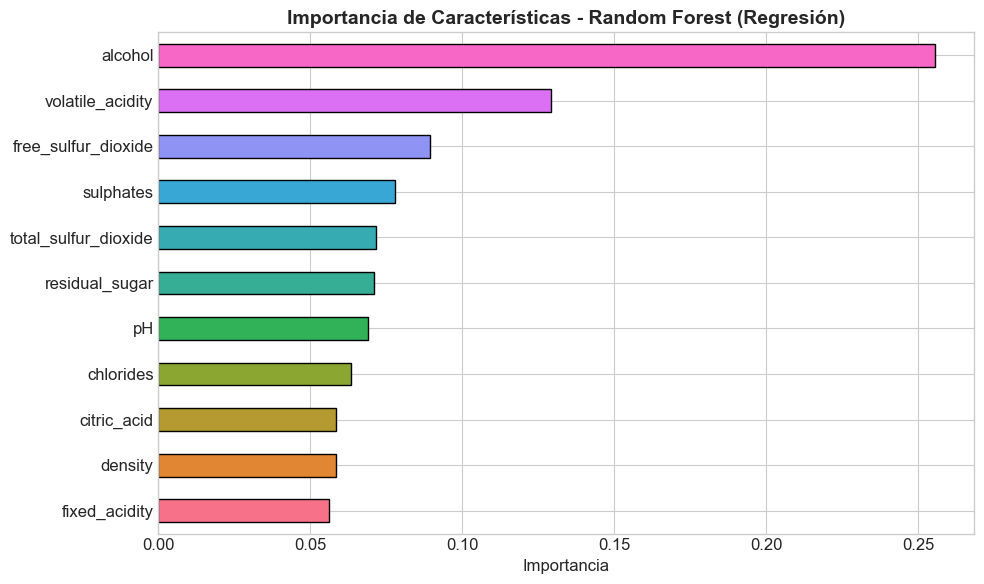


Justificación: Random Forest obtiene el mejor R² (0.5006)
y el menor MAE (0.4359), lo que indica que sus
predicciones son las más cercanas a los valores reales de calidad.

Este modelo captura mejor las relaciones no lineales en los datos y es
más robusto frente al sobreajuste comparado con un único árbol de decisión.


In [34]:
# Comparación visual de métricas
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metricas = ['MAE', 'MSE', 'RMSE', 'R²']
colores = sns.color_palette("husl", 3)

for i, metrica in enumerate(metricas):
    valores = df_resultados_reg[metrica].values
    nombres = df_resultados_reg.index
    bars = axes[i].bar(nombres, valores, color=colores, edgecolor='black')
    axes[i].set_title(metrica, fontsize=14, fontweight='bold')
    axes[i].set_ylabel(metrica)
    for bar, val in zip(bars, valores):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Comparación de Métricas - Modelos de Regresión',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Importancia de características del mejor modelo
print(f"\n{'='*60}")
print(f"SELECCIÓN: MEJOR MODELO DE REGRESIÓN -> {mejor_reg}")
print(f"{'='*60}")

if mejor_reg == 'Random Forest':
    best_model_reg = grid_rf_reg.best_estimator_
elif mejor_reg == 'Decision Tree':
    best_model_reg = grid_dt_reg.best_estimator_
else:
    best_model_reg = grid_br_reg.best_estimator_

# Mostrar importancia de características si el modelo lo soporta
if hasattr(best_model_reg, 'feature_importances_'):
    importances = best_model_reg.feature_importances_
    feature_names = X.columns
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    feat_imp.plot(kind='barh', color=sns.color_palette("husl", len(feat_imp)),
                  edgecolor='black', ax=ax)
    ax.set_xlabel('Importancia', fontsize=12)
    ax.set_title(f'Importancia de Características - {mejor_reg} (Regresión)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
elif hasattr(best_model_reg, 'coef_'):
    coefs = best_model_reg.coef_
    feature_names = X.columns
    feat_imp = pd.Series(np.abs(coefs), index=feature_names).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    feat_imp.plot(kind='barh', color=sns.color_palette("husl", len(feat_imp)),
                  edgecolor='black', ax=ax)
    ax.set_xlabel('|Coeficiente|', fontsize=12)
    ax.set_title(f'Importancia de Características - {mejor_reg} (Regresión)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print(f"\nJustificación: {mejor_reg} obtiene el mejor R² ({df_resultados_reg.loc[mejor_reg, 'R²']:.4f})")
print(f"y el menor MAE ({df_resultados_reg.loc[mejor_reg, 'MAE']:.4f}), lo que indica que sus")
print(f"predicciones son las más cercanas a los valores reales de calidad.")
print(f"\nEste modelo captura mejor las relaciones no lineales en los datos y es")
print(f"más robusto frente al sobreajuste comparado con un único árbol de decisión.")

---

## 9. CLASIFICACIÓN: Predicción de la Calidad como Variable Categórica

En esta sección tratamos la calidad del vino como una **variable categórica** y entrenamos tres modelos de clasificación:

1. **Random Forest Classifier:** Conjunto de árboles de decisión con votación mayoritaria.
2. **Decision Tree Classifier:** Un único árbol de decisión para clasificación.
3. **Gaussian Naive Bayes (GaussianNB):** Clasificador probabilístico basado en el teorema de Bayes con asunción de independencia entre características.

In [35]:
# ============================================================
# MODELO 1: Random Forest Classifier
# ============================================================
print("MODELO 1: RANDOM FOREST CLASSIFIER")
print("=" * 60)

param_grid_rf_clf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

rf_clf = RandomForestClassifier(random_state=42)
grid_rf_clf = GridSearchCV(
    rf_clf, param_grid_rf_clf,
    cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0
)
grid_rf_clf.fit(X_train_scaled, y_train_clf)

print(f"Mejores hiperparámetros: {grid_rf_clf.best_params_}")
print(f"Mejor F1-score (weighted) en validación cruzada: {grid_rf_clf.best_score_:.4f}")

y_pred_rf_clf = grid_rf_clf.predict(X_test_scaled)

MODELO 1: RANDOM FOREST CLASSIFIER
Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 100}
Mejor F1-score (weighted) en validación cruzada: 0.6563


In [36]:
# ============================================================
# MODELO 2: Decision Tree Classifier
# ============================================================
print("MODELO 2: DECISION TREE CLASSIFIER")
print("=" * 60)

param_grid_dt_clf = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

dt_clf = DecisionTreeClassifier(random_state=42)
grid_dt_clf = GridSearchCV(
    dt_clf, param_grid_dt_clf,
    cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0
)
grid_dt_clf.fit(X_train_scaled, y_train_clf)

print(f"Mejores hiperparámetros: {grid_dt_clf.best_params_}")
print(f"Mejor F1-score (weighted) en validación cruzada: {grid_dt_clf.best_score_:.4f}")

y_pred_dt_clf = grid_dt_clf.predict(X_test_scaled)

MODELO 2: DECISION TREE CLASSIFIER
Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor F1-score (weighted) en validación cruzada: 0.5833


In [37]:
# ============================================================
# MODELO 3: Gaussian Naive Bayes
# ============================================================
print("MODELO 3: GAUSSIAN NAIVE BAYES")
print("=" * 60)

param_grid_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
}

nb_clf = GaussianNB()
grid_nb_clf = GridSearchCV(
    nb_clf, param_grid_nb,
    cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0
)
grid_nb_clf.fit(X_train_scaled, y_train_clf)

print(f"Mejores hiperparámetros: {grid_nb_clf.best_params_}")
print(f"Mejor F1-score (weighted) en validación cruzada: {grid_nb_clf.best_score_:.4f}")

y_pred_nb_clf = grid_nb_clf.predict(X_test_scaled)

MODELO 3: GAUSSIAN NAIVE BAYES
Mejores hiperparámetros: {'var_smoothing': 0.1}
Mejor F1-score (weighted) en validación cruzada: 0.4534


## 10. Evaluación de los Modelos de Clasificación

Evaluamos los tres modelos de clasificación con las métricas: **Accuracy**, **F1-Score** (weighted y macro), **Precision**, **Recall**, **Matriz de Confusión** y **Curva ROC** (One-vs-Rest).

In [38]:
# Calcular métricas para los tres modelos de clasificación
modelos_clf = {
    'Random Forest': y_pred_rf_clf,
    'Decision Tree': y_pred_dt_clf,
    'Naive Bayes': y_pred_nb_clf
}

resultados_clf = {}
for nombre, y_pred in modelos_clf.items():
    acc = accuracy_score(y_test_clf, y_pred)
    f1_w = f1_score(y_test_clf, y_pred, average='weighted', zero_division=0)
    f1_m = f1_score(y_test_clf, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_test_clf, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_clf, y_pred, average='weighted', zero_division=0)
    resultados_clf[nombre] = {
        'Accuracy': acc,
        'F1 (weighted)': f1_w,
        'F1 (macro)': f1_m,
        'Precision': prec,
        'Recall': rec
    }

# Tabla comparativa
df_resultados_clf = pd.DataFrame(resultados_clf).T
df_resultados_clf = df_resultados_clf.round(4)

print("TABLA COMPARATIVA - MODELOS DE CLASIFICACIÓN")
print("=" * 60)
print(df_resultados_clf.to_string())

mejor_clf = df_resultados_clf['F1 (weighted)'].idxmax()
print(f"\n★ Mejor modelo de clasificación: {mejor_clf} (F1 weighted = {df_resultados_clf.loc[mejor_clf, 'F1 (weighted)']:.4f})")

TABLA COMPARATIVA - MODELOS DE CLASIFICACIÓN
               Accuracy  F1 (weighted)  F1 (macro)  Precision  Recall
Random Forest    0.6677         0.6560      0.3847     0.6722  0.6677
Decision Tree    0.6162         0.6156      0.3567     0.6157  0.6162
Naive Bayes      0.4715         0.4652      0.2499     0.5049  0.4715

★ Mejor modelo de clasificación: Random Forest (F1 weighted = 0.6560)


In [39]:
# Classification Report detallado para cada modelo
for nombre, y_pred in modelos_clf.items():
    print(f"\n{'='*60}")
    print(f"CLASSIFICATION REPORT - {nombre}")
    print(f"{'='*60}")
    print(classification_report(y_test_clf, y_pred, zero_division=0))


CLASSIFICATION REPORT - Random Forest
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.71      0.12      0.20        43
           5       0.67      0.72      0.69       402
           6       0.65      0.75      0.70       597
           7       0.69      0.55      0.61       215
           8       0.92      0.33      0.49        36
           9       0.00      0.00      0.00         1

    accuracy                           0.67      1300
   macro avg       0.52      0.35      0.38      1300
weighted avg       0.67      0.67      0.66      1300


CLASSIFICATION REPORT - Decision Tree
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.28      0.26      0.27        43
           5       0.64      0.66      0.65       402
           6       0.66      0.64      0.65       597
           7       0.57      0.61      0.59       215


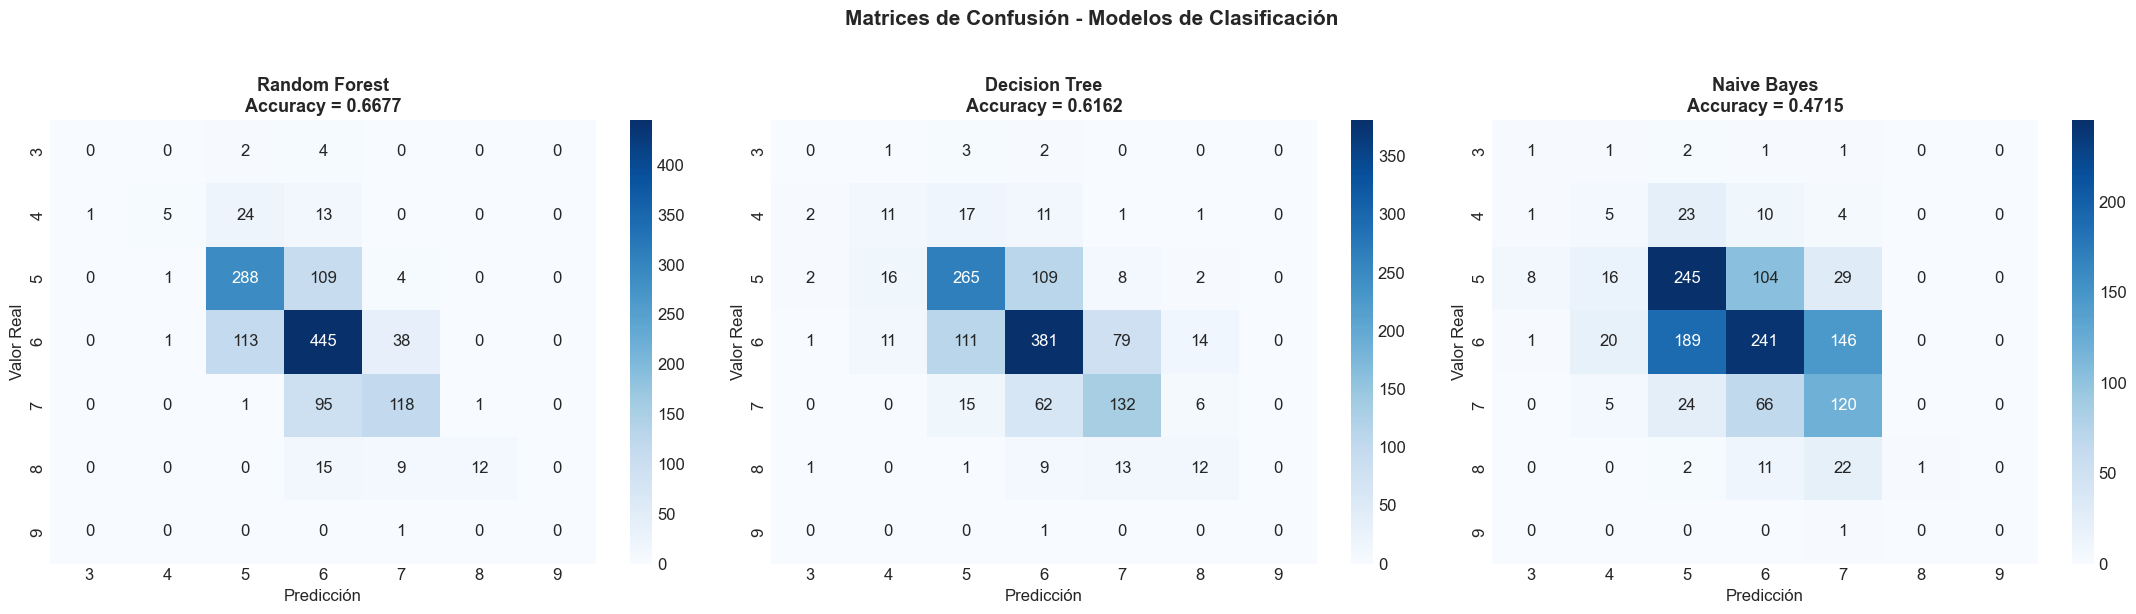

In [40]:
# Matrices de confusión para los tres modelos
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
clases = sorted(np.unique(y_test_clf))

for i, (nombre, y_pred) in enumerate(modelos_clf.items()):
    cm = confusion_matrix(y_test_clf, y_pred, labels=clases)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=clases, yticklabels=clases)
    axes[i].set_xlabel('Predicción', fontsize=12)
    axes[i].set_ylabel('Valor Real', fontsize=12)
    acc = resultados_clf[nombre]['Accuracy']
    axes[i].set_title(f'{nombre}\nAccuracy = {acc:.4f}', fontsize=13, fontweight='bold')

plt.suptitle('Matrices de Confusión - Modelos de Clasificación',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

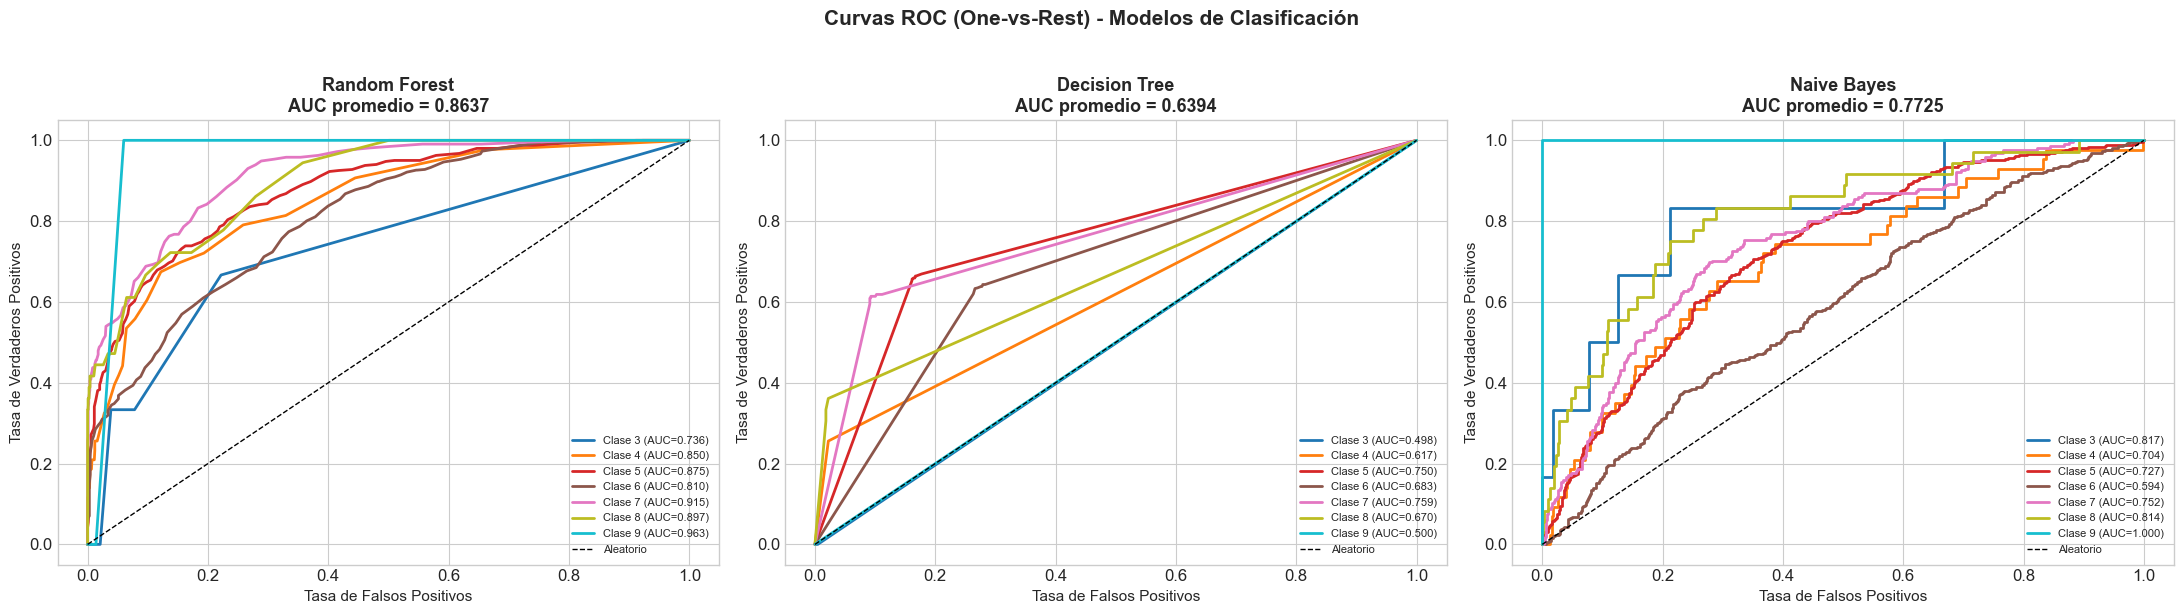

In [41]:
# Curvas ROC (One-vs-Rest) para los tres modelos
clases_all = sorted(np.unique(np.concatenate([y_train_clf, y_test_clf])))

# Binarizar las etiquetas para ROC multiclase
y_test_bin = label_binarize(y_test_clf, classes=clases_all)
n_classes = y_test_bin.shape[1]

# Obtener probabilidades de cada modelo
modelos_grid = {
    'Random Forest': grid_rf_clf,
    'Decision Tree': grid_dt_clf,
    'Naive Bayes': grid_nb_clf
}

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for idx, (nombre, grid_model) in enumerate(modelos_grid.items()):
    y_prob = grid_model.predict_proba(X_test_scaled)

    # Asegurar que las columnas de probabilidad coinciden con las clases
    model_classes = grid_model.best_estimator_.classes_

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i, clase in enumerate(clases_all):
        if clase in model_classes:
            class_idx = list(model_classes).index(clase)
            bin_idx = clases_all.index(clase)
            fpr[clase], tpr[clase], _ = roc_curve(y_test_bin[:, bin_idx], y_prob[:, class_idx])
            roc_auc[clase] = auc(fpr[clase], tpr[clase])

    # Graficar curvas ROC por clase
    colores_roc = plt.cm.tab10(np.linspace(0, 1, len(clases_all)))
    for i, clase in enumerate(clases_all):
        if clase in roc_auc:
            axes[idx].plot(fpr[clase], tpr[clase], color=colores_roc[i],
                          linewidth=2, label=f'Clase {clase} (AUC={roc_auc[clase]:.3f})')

    axes[idx].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio')
    axes[idx].set_xlabel('Tasa de Falsos Positivos', fontsize=11)
    axes[idx].set_ylabel('Tasa de Verdaderos Positivos', fontsize=11)

    # AUC promedio
    mean_auc = np.mean(list(roc_auc.values()))
    axes[idx].set_title(f'{nombre}\nAUC promedio = {mean_auc:.4f}', fontsize=13, fontweight='bold')
    axes[idx].legend(fontsize=8, loc='lower right')

plt.suptitle('Curvas ROC (One-vs-Rest) - Modelos de Clasificación',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Selección del Mejor Modelo de Clasificación

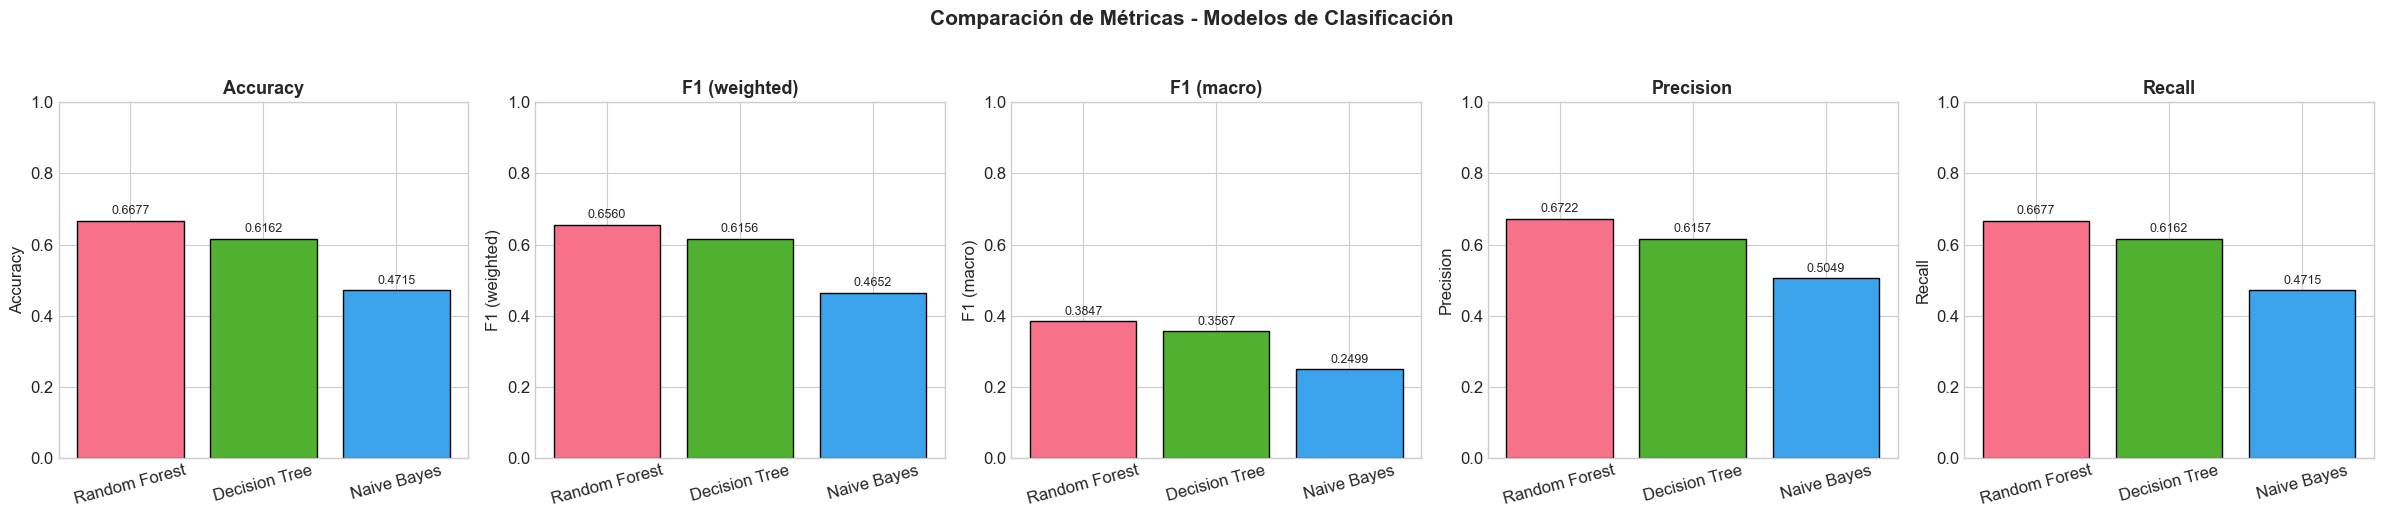


SELECCIÓN: MEJOR MODELO DE CLASIFICACIÓN -> Random Forest


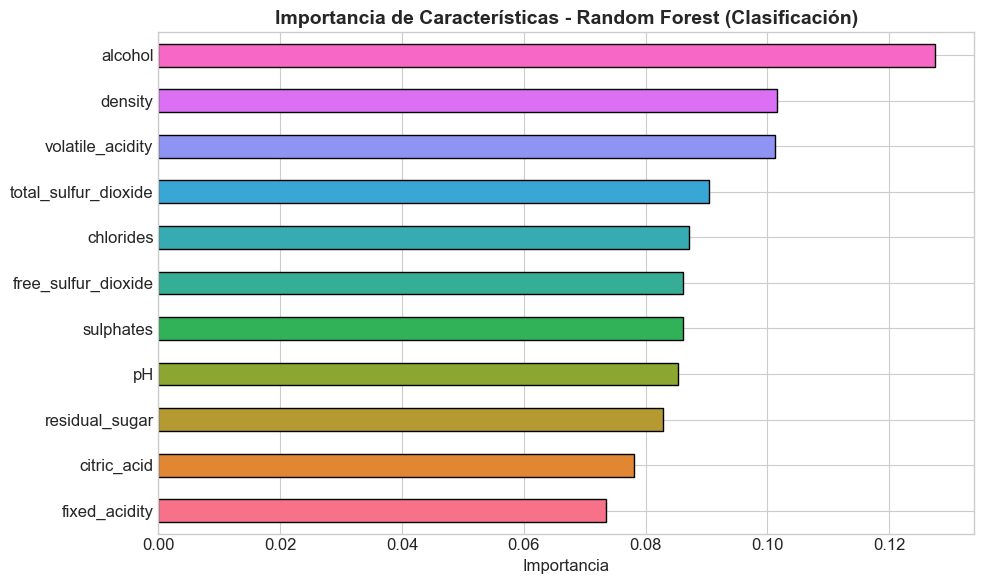


Justificación: Random Forest obtiene el mejor F1-score weighted
(0.6560) y la mejor accuracy
(0.6677).

Random Forest es superior porque combina múltiples árboles de decisión,
reduciendo la varianza y el sobreajuste. Decision Tree tiende a sobreajustarse
a los datos de entrenamiento, mientras que Naive Bayes asume independencia
entre características, lo cual no se cumple en este dataset.


In [42]:
# Comparación visual de métricas de clasificación
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
metricas_clf = ['Accuracy', 'F1 (weighted)', 'F1 (macro)', 'Precision', 'Recall']
colores = sns.color_palette("husl", 3)

for i, metrica in enumerate(metricas_clf):
    valores = df_resultados_clf[metrica].values
    nombres = df_resultados_clf.index
    bars = axes[i].bar(nombres, valores, color=colores, edgecolor='black')
    axes[i].set_title(metrica, fontsize=13, fontweight='bold')
    axes[i].set_ylabel(metrica)
    axes[i].set_ylim(0, 1)
    for bar, val in zip(bars, valores):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Comparación de Métricas - Modelos de Clasificación',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Selección del mejor modelo de clasificación
print(f"\n{'='*60}")
print(f"SELECCIÓN: MEJOR MODELO DE CLASIFICACIÓN -> {mejor_clf}")
print(f"{'='*60}")

if mejor_clf == 'Random Forest':
    best_model_clf = grid_rf_clf.best_estimator_
elif mejor_clf == 'Decision Tree':
    best_model_clf = grid_dt_clf.best_estimator_
else:
    best_model_clf = grid_nb_clf.best_estimator_

# Importancia de características si el modelo lo soporta
if hasattr(best_model_clf, 'feature_importances_'):
    importances = best_model_clf.feature_importances_
    feature_names = X.columns
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    feat_imp.plot(kind='barh', color=sns.color_palette("husl", len(feat_imp)),
                  edgecolor='black', ax=ax)
    ax.set_xlabel('Importancia', fontsize=12)
    ax.set_title(f'Importancia de Características - {mejor_clf} (Clasificación)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print(f"\nJustificación: {mejor_clf} obtiene el mejor F1-score weighted")
print(f"({df_resultados_clf.loc[mejor_clf, 'F1 (weighted)']:.4f}) y la mejor accuracy")
print(f"({df_resultados_clf.loc[mejor_clf, 'Accuracy']:.4f}).")
print(f"\nRandom Forest es superior porque combina múltiples árboles de decisión,")
print(f"reduciendo la varianza y el sobreajuste. Decision Tree tiende a sobreajustarse")
print(f"a los datos de entrenamiento, mientras que Naive Bayes asume independencia")
print(f"entre características, lo cual no se cumple en este dataset.")

---

## 12. Comparación Final: Regresión vs Clasificación

En esta sección comparamos el mejor modelo de regresión con el mejor modelo de clasificación para determinar qué enfoque funciona mejor para predecir la calidad del vino.

### Sobre la naturaleza del problema

La variable `quality` toma valores enteros discretos (3-9), lo que la hace:
- **Similar a una variable continua**: Tiene un orden natural (5 < 6 < 7).
- **Similar a una variable categórica**: Solo toma valores discretos y limitados.

Esto hace que tanto la regresión como la clasificación sean enfoques válidos. Para una comparación justa, convertiremos las predicciones de regresión a clases discretas (redondeando) y calcularemos métricas de clasificación.

In [43]:
# ============================================================
# COMPARACIÓN DIRECTA: REGRESIÓN vs CLASIFICACIÓN
# ============================================================
print("COMPARACIÓN FINAL: REGRESIÓN vs CLASIFICACIÓN")
print("=" * 60)

# Obtener las predicciones del mejor modelo de regresión
if mejor_reg == 'Random Forest':
    y_pred_best_reg = y_pred_rf_reg
elif mejor_reg == 'Decision Tree':
    y_pred_best_reg = y_pred_dt_reg
else:
    y_pred_best_reg = y_pred_br_reg

# Obtener las predicciones del mejor modelo de clasificación
if mejor_clf == 'Random Forest':
    y_pred_best_clf = y_pred_rf_clf
elif mejor_clf == 'Decision Tree':
    y_pred_best_clf = y_pred_dt_clf
else:
    y_pred_best_clf = y_pred_nb_clf

# Convertir predicciones de regresión a clases discretas (redondeando)
y_pred_reg_rounded = np.clip(np.round(y_pred_best_reg).astype(int),
                              y_test_clf.min(), y_test_clf.max())

# Métricas del mejor modelo de regresión
print(f"\nMejor modelo de REGRESIÓN: {mejor_reg}")
print(f"  - R²:   {resultados_reg[mejor_reg]['R²']:.4f}")
print(f"  - MAE:  {resultados_reg[mejor_reg]['MAE']:.4f}")
print(f"  - MSE:  {resultados_reg[mejor_reg]['MSE']:.4f}")
print(f"  - RMSE: {resultados_reg[mejor_reg]['RMSE']:.4f}")

print(f"\nMejor modelo de CLASIFICACIÓN: {mejor_clf}")
print(f"  - Accuracy:      {resultados_clf[mejor_clf]['Accuracy']:.4f}")
print(f"  - F1 (weighted): {resultados_clf[mejor_clf]['F1 (weighted)']:.4f}")
print(f"  - F1 (macro):    {resultados_clf[mejor_clf]['F1 (macro)']:.4f}")
print(f"  - Precision:     {resultados_clf[mejor_clf]['Precision']:.4f}")
print(f"  - Recall:        {resultados_clf[mejor_clf]['Recall']:.4f}")

# Comparación usando predicciones redondeadas de regresión como clasificación
print(f"\n{'─'*60}")
print("COMPARACIÓN DIRECTA (predicciones de regresión redondeadas como clases):")
print(f"{'─'*60}")

acc_reg_as_clf = accuracy_score(y_test_clf, y_pred_reg_rounded)
f1_reg_as_clf = f1_score(y_test_clf, y_pred_reg_rounded, average='weighted', zero_division=0)
acc_clf = accuracy_score(y_test_clf, y_pred_best_clf)
f1_clf = f1_score(y_test_clf, y_pred_best_clf, average='weighted', zero_division=0)

comparacion = pd.DataFrame({
    f'Regresión ({mejor_reg}) redondeado': {
        'Accuracy': acc_reg_as_clf,
        'F1 (weighted)': f1_reg_as_clf
    },
    f'Clasificación ({mejor_clf})': {
        'Accuracy': acc_clf,
        'F1 (weighted)': f1_clf
    }
}).round(4)

print(comparacion.to_string())

COMPARACIÓN FINAL: REGRESIÓN vs CLASIFICACIÓN

Mejor modelo de REGRESIÓN: Random Forest
  - R²:   0.5006
  - MAE:  0.4359
  - MSE:  0.3688
  - RMSE: 0.6073

Mejor modelo de CLASIFICACIÓN: Random Forest
  - Accuracy:      0.6677
  - F1 (weighted): 0.6560
  - F1 (macro):    0.3847
  - Precision:     0.6722
  - Recall:        0.6677

────────────────────────────────────────────────────────────
COMPARACIÓN DIRECTA (predicciones de regresión redondeadas como clases):
────────────────────────────────────────────────────────────
               Regresión (Random Forest) redondeado  Clasificación (Random Forest)
Accuracy                                     0.6754                         0.6677
F1 (weighted)                                0.6593                         0.6560


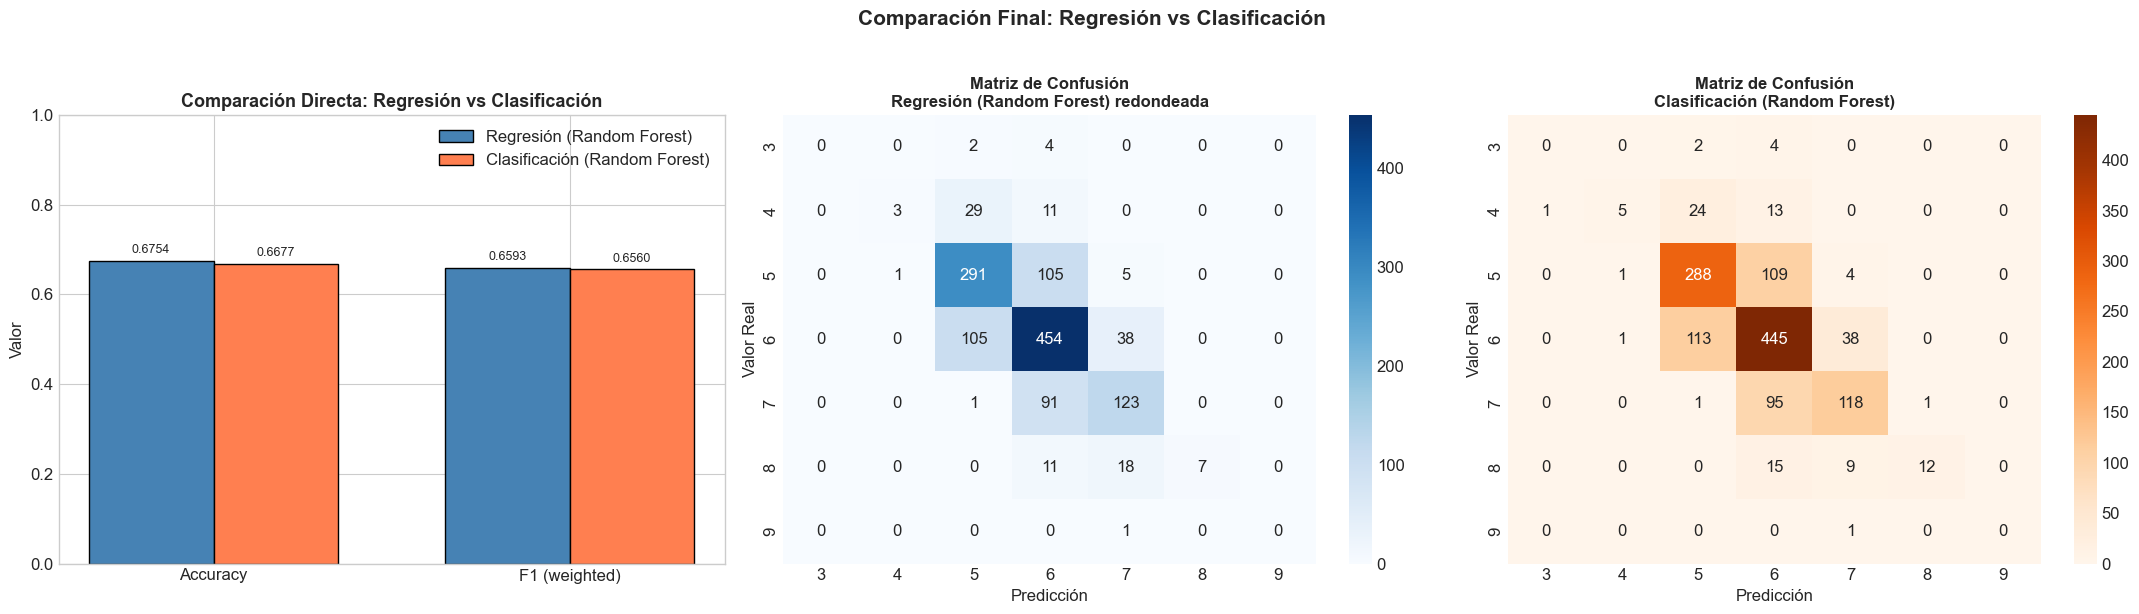

In [44]:
# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. Comparación Accuracy y F1-score
metricas_comp = ['Accuracy', 'F1 (weighted)']
x = np.arange(len(metricas_comp))
width = 0.35

vals_reg = [acc_reg_as_clf, f1_reg_as_clf]
vals_clf = [acc_clf, f1_clf]

bars1 = axes[0].bar(x - width/2, vals_reg, width,
                     label=f'Regresión ({mejor_reg})', color='steelblue', edgecolor='black')
bars2 = axes[0].bar(x + width/2, vals_clf, width,
                     label=f'Clasificación ({mejor_clf})', color='coral', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas_comp)
axes[0].set_ylabel('Valor')
axes[0].set_title('Comparación Directa: Regresión vs Clasificación',
                   fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1)
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

# 2. Matriz de confusión: Regresión redondeada
cm_reg = confusion_matrix(y_test_clf, y_pred_reg_rounded, labels=clases)
sns.heatmap(cm_reg, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=clases, yticklabels=clases)
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')
axes[1].set_title(f'Matriz de Confusión\nRegresión ({mejor_reg}) redondeada',
                   fontsize=12, fontweight='bold')

# 3. Matriz de confusión: Clasificación
cm_clf = confusion_matrix(y_test_clf, y_pred_best_clf, labels=clases)
sns.heatmap(cm_clf, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=clases, yticklabels=clases)
axes[2].set_xlabel('Predicción')
axes[2].set_ylabel('Valor Real')
axes[2].set_title(f'Matriz de Confusión\nClasificación ({mejor_clf})',
                   fontsize=12, fontweight='bold')

plt.suptitle('Comparación Final: Regresión vs Clasificación',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 13. Conclusiones

### Resumen de Resultados

In [45]:
# Resumen final
print("=" * 70)
print("                    RESUMEN FINAL DE RESULTADOS")
print("=" * 70)

print(f"\nREGRESIÓN (mejor modelo: {mejor_reg})")
print(f"   R²:   {resultados_reg[mejor_reg]['R²']:.4f}")
print(f"   MAE:  {resultados_reg[mejor_reg]['MAE']:.4f}")
print(f"   MSE:  {resultados_reg[mejor_reg]['MSE']:.4f}")
print(f"   RMSE: {resultados_reg[mejor_reg]['RMSE']:.4f}")

print(f"\nCLASIFICACIÓN (mejor modelo: {mejor_clf})")
print(f"   Accuracy:      {resultados_clf[mejor_clf]['Accuracy']:.4f}")
print(f"   F1 (weighted): {resultados_clf[mejor_clf]['F1 (weighted)']:.4f}")
print(f"   F1 (macro):    {resultados_clf[mejor_clf]['F1 (macro)']:.4f}")
print(f"   Precision:     {resultados_clf[mejor_clf]['Precision']:.4f}")
print(f"   Recall:        {resultados_clf[mejor_clf]['Recall']:.4f}")

print(f"\nCOMPARACIÓN DIRECTA (regresión redondeada como clasificación)")
print(f"   Accuracy Regresión:      {acc_reg_as_clf:.4f}")
print(f"   Accuracy Clasificación:  {acc_clf:.4f}")
print(f"   F1 Regresión:            {f1_reg_as_clf:.4f}")
print(f"   F1 Clasificación:        {f1_clf:.4f}")

print(f"\n{'='*70}")
print("CONCLUSIONES")
print(f"{'='*70}")
print(f"""
1. MEJOR MODELO DE REGRESIÓN: {mejor_reg}
   - Obtuvo el mejor R² y menor error (MAE, MSE) entre los tres modelos probados.
   - Random Forest es superior al árbol de decisión simple porque combina
     múltiples árboles, reduciendo la varianza y el sobreajuste.
   - BayesianRidge, siendo un modelo lineal, no captura bien las relaciones
     no lineales presentes en los datos.

2. MEJOR MODELO DE CLASIFICACIÓN: {mejor_clf}
   - Obtuvo el mejor F1-score y accuracy entre los tres modelos probados.
   - La ventaja sobre Decision Tree se debe a la reducción de varianza
     mediante el ensamblaje de múltiples árboles.
   - GaussianNB asume independencia entre características, lo cual no se
     cumple en este dataset (las propiedades químicas están correlacionadas).

3. REGRESIÓN vs CLASIFICACIÓN:
   - La variable 'quality' es ordinal con valores discretos (3-9), lo que
     la hace más natural como variable categórica.
   - Sin embargo, el enfoque de regresión puede capturar la relación ordinal
     entre las clases (un error de 5->6 es menor que de 5->8).
   - Ambos enfoques son válidos para este problema. La elección depende
     del contexto de uso: si se necesita una puntuación exacta (clasificación)
     o una estimación continua (regresión).

4. REFLEXIÓN FINAL:
   - Los modelos basados en Random Forest dominan en ambos enfoques,
     confirmando su robustez para este tipo de datos tabulares.
   - El desbalance de clases (pocas muestras en calidades extremas)
     afecta especialmente a la clasificación, donde las clases minoritarias
     tienen bajo recall.
   - Para mejorar los resultados, se podría explorar: técnicas de balanceo
     de clases (SMOTE), ingeniería de características, o modelos más
     avanzados como Gradient Boosting (XGBoost, LightGBM).
""")

                    RESUMEN FINAL DE RESULTADOS

REGRESIÓN (mejor modelo: Random Forest)
   R²:   0.5006
   MAE:  0.4359
   MSE:  0.3688
   RMSE: 0.6073

CLASIFICACIÓN (mejor modelo: Random Forest)
   Accuracy:      0.6677
   F1 (weighted): 0.6560
   F1 (macro):    0.3847
   Precision:     0.6722
   Recall:        0.6677

COMPARACIÓN DIRECTA (regresión redondeada como clasificación)
   Accuracy Regresión:      0.6754
   Accuracy Clasificación:  0.6677
   F1 Regresión:            0.6593
   F1 Clasificación:        0.6560

CONCLUSIONES

1. MEJOR MODELO DE REGRESIÓN: Random Forest
   - Obtuvo el mejor R² y menor error (MAE, MSE) entre los tres modelos probados.
   - Random Forest es superior al árbol de decisión simple porque combina
     múltiples árboles, reduciendo la varianza y el sobreajuste.
   - BayesianRidge, siendo un modelo lineal, no captura bien las relaciones
     no lineales presentes en los datos.

2. MEJOR MODELO DE CLASIFICACIÓN: Random Forest
   - Obtuvo el mejor F1-scor